
# 🏷️ Naive Bayes Classification - The Simpson

Aquest notebook pretén mostrar un exempl d'ús de'un model de classificació  **Naive Bayes** per poder determinar quin personatge de la sèrie Els Simpson diu la frase.
Per exemple és sabut que l'expressió "Eat my shorts" és molt utilitzada per Bart, o l'expressió "[D'Oh](https://www.youtube.com/watch?v=6hyOLydRFfU)" per el part Homer.

![image](https://upload.wikimedia.org/wikipedia/en/c/ca/Simpsons_cast.png)

---

## 🎯 Objectius
-

## 📦 Dataset Simpson DataSet

És un dataset públic al repositori de [Kaggle](https://www.kaggle.com/datasets/pierremegret/dialogue-lines-of-the-simpsons/data):

* 158314 diàlegs/texts
* 6759 personatges

* Cada registre té:

  * `raw_character_text`: Personatge que diu la frase
  * `spoken_words`: contingut de la frase

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import numpy as np
import os as os
from google.colab import drive
drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/Colab Notebooks/M0572-SistemesAprenentatgeAutomatic/02_models_supervisats/')
p = os.getcwd()
#print(p)

# Carregar dataset
# Format esperat: dos camps: 'raw_character_text' i 'spoken_words'
df = pd.read_csv("dataset/simpsons_dataset.csv",sep=",", header=0, names=["personatge","text"])

df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(158314, 2)

In [ ]:
df = df[df["text"].apply(lambda x: isinstance(x, str))].copy()

In [ ]:
personatges = []
personatges.append("Homer Simpson")
personatges.append("Marge Simpson")
personatges.append("Bart Simpson")
personatges.append("Lisa Simpson")
#personatges.append("Moe Szyslak")

print(personatges)
#Filtrem només per els personatges principals (Homer, Bart, Lisa, Marge)
df = df[df["personatge"].isin(personatges)]


['Homer Simpson', 'Marge Simpson', 'Bart Simpson', 'Lisa Simpson']


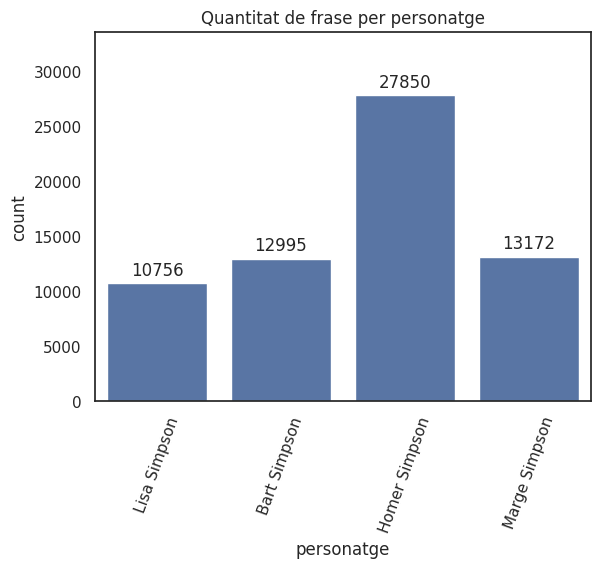

In [ ]:
def mostrarBarPlotXPErsonatge(df):
  ## Mostrar un bar plot amb la quantiat de frases per cada personatge
  import seaborn as sns
  import matplotlib.pyplot as plt

  ax = sns.countplot(
      data=df,
      x='personatge',
  )
  plt.ylim(0, ax.get_ylim()[1] * 1.15) # Afegeixo espai per evitar que el text quedi tallat
  # Afegir valors damunt de cada barra
  for bar in ax.patches:
      h = bar.get_height()
      ax.annotate(
          f'{h:.0f}',
          (bar.get_x() + bar.get_width()/2, h),
          ha='center',
          va='bottom',
          fontsize=12,
          xytext=(0, 3),
          textcoords='offset points'
      )
  plt.xticks(rotation=70)

  plt.title("Quantitat de frase per personatge")
  plt.show()

mostrarBarPlotXPErsonatge(df)

## Preparar model

## Preprocessat del text

## Preprocessat del text